# Lakhan Singh | Reg No. 2411021240058
# Assignment 4 — Training a DCGAN on Fashion-MNIST

**Objective:** Train a Deep Convolutional Generative Adversarial Network (DCGAN) on Fashion-MNIST and observe how generated clothing images improve during training.


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

BATCH_SIZE = 128
LATENT_DIM = 100
EPOCHS = 30
LR = 0.0002
BETA1 = 0.5

os.makedirs("dcgan_outputs", exist_ok=True)

Device: cuda


## 1. Load Fashion-MNIST

Fashion-MNIST contains 28 × 28 grayscale clothing images. The images are normalized to approximately **[-1, 1]** because the Generator uses `Tanh` as its final activation.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Training images:", len(train_dataset))
print("Number of batches:", len(train_loader))
print("Classes:", train_dataset.classes)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 179kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.34MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.89MB/s]

Training images: 60000
Number of batches: 469
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


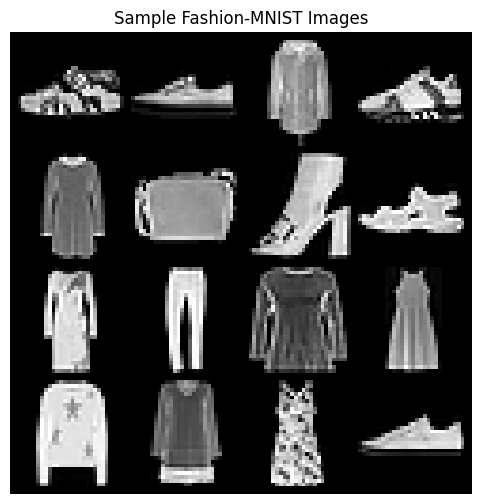

In [ ]:
images, labels = next(iter(train_loader))
grid = utils.make_grid(images[:16], nrow=4, normalize=True)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title("Sample Fashion-MNIST Images")
plt.axis("off")
plt.show()

## 2. Generator

The Generator starts with a random latent vector and uses **transposed convolution layers** to create a 28 × 28 image.

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Conv2d(32, 1, 3, 1, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

G = Generator(LATENT_DIM).to(device)
print(G)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)


## 3. Discriminator

The Discriminator uses **convolution layers** to classify an image as real (1) or generated/fake (0).

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

D = Discriminator().to(device)
print(D)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=6272, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


## 4. Loss function, weight initialization, and optimizers

Binary Cross Entropy is used because the Discriminator performs real/fake binary classification.

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    G.parameters(), lr=LR, betas=(BETA1, 0.999)
)
optimizer_D = optim.Adam(
    D.parameters(), lr=LR, betas=(BETA1, 0.999)
)

fixed_noise = torch.randn(16, LATENT_DIM, 1, 1, device=device)

print("Models and optimizers are ready.")

Models and optimizers are ready.


## 5. Train the DCGAN

The Discriminator learns to distinguish real images from generated images, while the Generator learns to produce images that fool the Discriminator.

A **fixed noise vector** is used for every saved grid, making visual comparison across epochs meaningful.

Required checkpoints: **5, 10, 15, 20, 25, and 30 epochs**.

Epoch [01/30] | D Loss: 0.7321 | G Loss: 1.6239
Epoch [02/30] | D Loss: 0.8393 | G Loss: 1.5350
Epoch [03/30] | D Loss: 1.0380 | G Loss: 1.2384
Epoch [04/30] | D Loss: 1.0502 | G Loss: 1.2058
Epoch [05/30] | D Loss: 1.0916 | G Loss: 1.1589


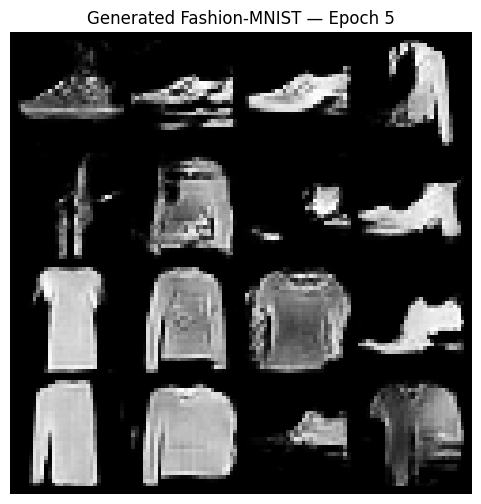

Epoch [06/30] | D Loss: 1.1079 | G Loss: 1.1349
Epoch [07/30] | D Loss: 1.1279 | G Loss: 1.1238
Epoch [08/30] | D Loss: 1.1556 | G Loss: 1.1114
Epoch [09/30] | D Loss: 1.1571 | G Loss: 1.0857
Epoch [10/30] | D Loss: 1.1843 | G Loss: 1.0795


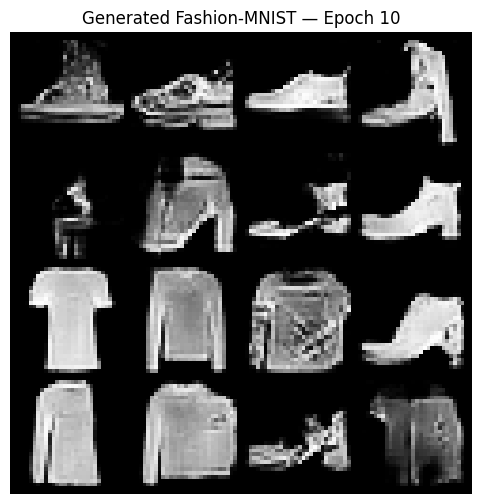

Epoch [11/30] | D Loss: 1.1816 | G Loss: 1.0657
Epoch [12/30] | D Loss: 1.1897 | G Loss: 1.0589
Epoch [13/30] | D Loss: 1.1981 | G Loss: 1.0575
Epoch [14/30] | D Loss: 1.1992 | G Loss: 1.0508
Epoch [15/30] | D Loss: 1.2123 | G Loss: 1.0430


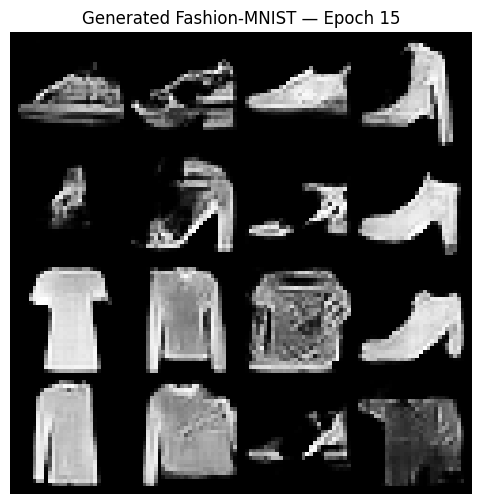

Epoch [16/30] | D Loss: 1.2019 | G Loss: 1.0437
Epoch [17/30] | D Loss: 1.2107 | G Loss: 1.0435
Epoch [18/30] | D Loss: 1.2117 | G Loss: 1.0398
Epoch [19/30] | D Loss: 1.2133 | G Loss: 1.0371
Epoch [20/30] | D Loss: 1.2162 | G Loss: 1.0407


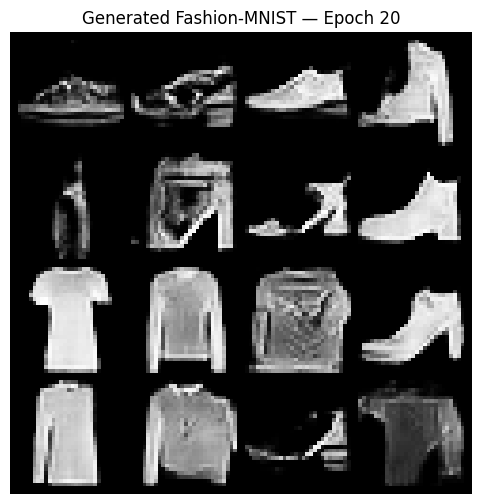

Epoch [21/30] | D Loss: 1.2142 | G Loss: 1.0268
Epoch [22/30] | D Loss: 1.2296 | G Loss: 1.0416
Epoch [23/30] | D Loss: 1.2180 | G Loss: 1.0303
Epoch [24/30] | D Loss: 1.2207 | G Loss: 1.0313
Epoch [25/30] | D Loss: 1.2258 | G Loss: 1.0295


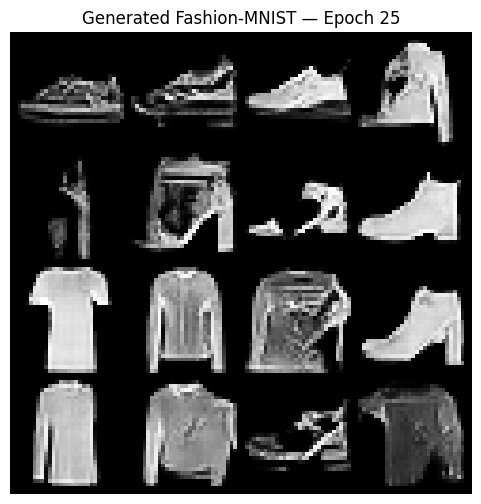

Epoch [26/30] | D Loss: 1.2230 | G Loss: 1.0293
Epoch [27/30] | D Loss: 1.2217 | G Loss: 1.0269
Epoch [28/30] | D Loss: 1.2234 | G Loss: 1.0291
Epoch [29/30] | D Loss: 1.2210 | G Loss: 1.0267
Epoch [30/30] | D Loss: 1.2185 | G Loss: 1.0278


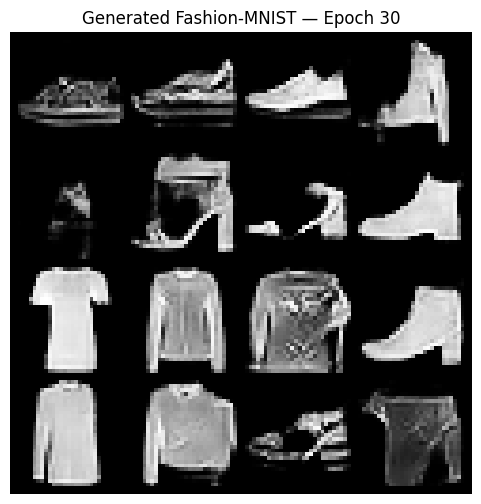

Training complete!


In [ ]:
G_losses = []
D_losses = []
epoch_G_losses = []
epoch_D_losses = []

def save_generated_grid(epoch):
    G.eval()
    with torch.no_grad():
        fake = G(fixed_noise).detach().cpu()

    path = f"dcgan_outputs/generated_epoch_{epoch:02d}.png"
    utils.save_image(
        fake, path, nrow=4, normalize=True, padding=2
    )

    grid = utils.make_grid(fake, nrow=4, normalize=True, padding=2)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.title(f"Generated Fashion-MNIST — Epoch {epoch}")
    plt.axis("off")
    plt.show()

    G.train()

for epoch in range(1, EPOCHS + 1):
    running_G = 0.0
    running_D = 0.0

    for real_images, _ in train_loader:
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Train Discriminator
        optimizer_D.zero_grad(set_to_none=True)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        real_output = D(real_images)
        loss_D_real = criterion(real_output, real_labels)

        noise = torch.randn(
            batch_size, LATENT_DIM, 1, 1, device=device
        )
        fake_images = G(noise)

        fake_output = D(fake_images.detach())
        loss_D_fake = criterion(fake_output, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad(set_to_none=True)

        output = D(fake_images)
        loss_G = criterion(output, real_labels)

        loss_G.backward()
        optimizer_G.step()

        running_D += loss_D.item()
        running_G += loss_G.item()
        D_losses.append(loss_D.item())
        G_losses.append(loss_G.item())

    avg_D = running_D / len(train_loader)
    avg_G = running_G / len(train_loader)

    epoch_D_losses.append(avg_D)
    epoch_G_losses.append(avg_G)

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] | "
        f"D Loss: {avg_D:.4f} | G Loss: {avg_G:.4f}"
    )

    if epoch % 5 == 0:
        save_generated_grid(epoch)

print("Training complete!")

## 6. Plot Generator and Discriminator losses

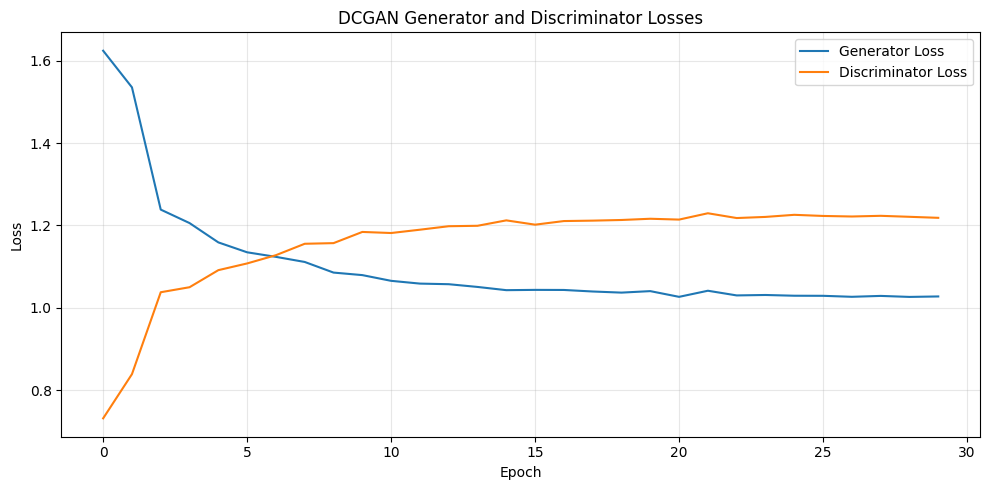

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(epoch_G_losses, label="Generator Loss")
plt.plot(epoch_D_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Generator and Discriminator Losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("dcgan_outputs/loss_graph.png", dpi=200)
plt.show()

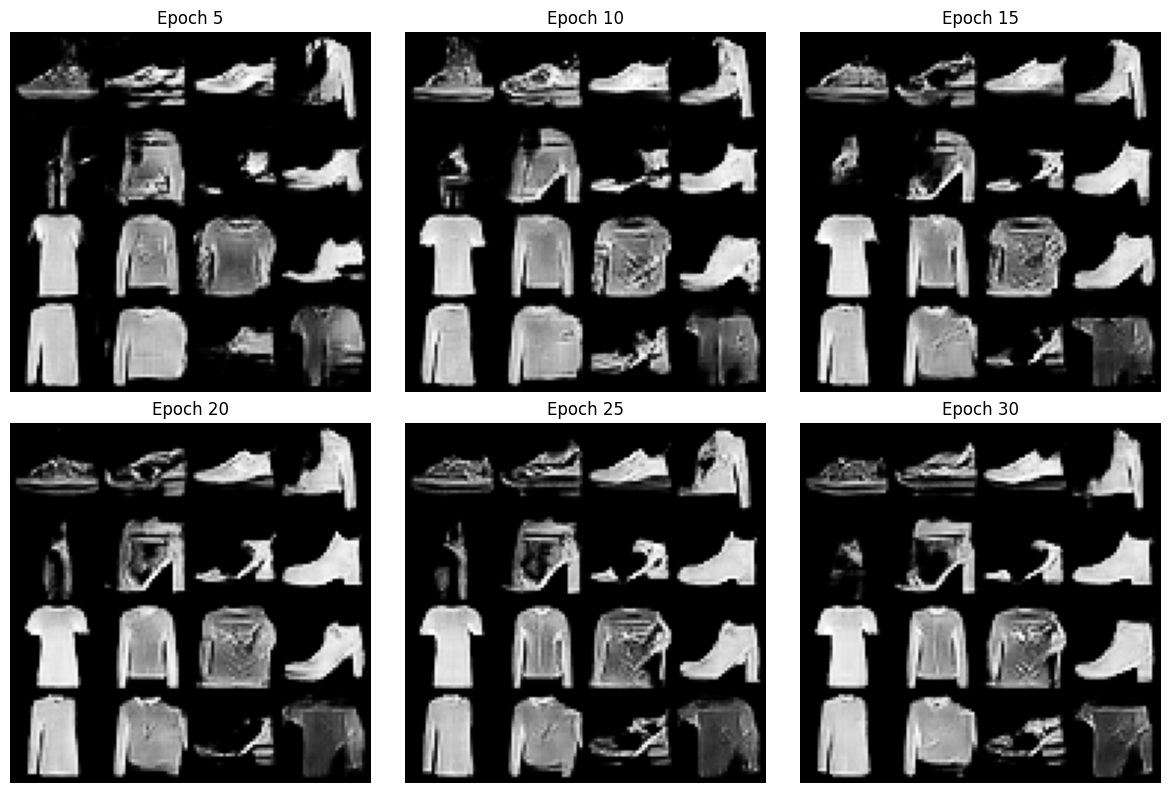

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, epoch in zip(axes.ravel(), [5, 10, 15, 20, 25, 30]):
    path = f"dcgan_outputs/generated_epoch_{epoch:02d}.png"
    img = plt.imread(path)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Epoch {epoch}")
    ax.axis("off")

plt.tight_layout()
plt.savefig("dcgan_outputs/all_epochs_comparison.png", dpi=200)
plt.show()

Q1. How do the generated images change from Epoch 5 to Epoch 25?

Answer: At Epoch 5, the generated images already show recognizable basic clothing shapes, although some images are blurry and contain artifacts. From Epochs 10 to 15, the shapes become cleaner and more defined. By Epochs 20–25, items such as shoes, tops, trousers, and bags are clearer and more consistent. The improvement becomes smaller in the later epochs.

Q2. Can you observe instability during training?

Answer: No major training instability is visible. The losses change substantially during the early epochs but gradually stabilize. For example, Generator loss decreases from 1.6239 at Epoch 1 to 1.0278 at Epoch 30, while Discriminator loss moves from 0.7321 to 1.2185. In the later epochs, both losses fluctuate only slightly, indicating relatively stable adversarial training.

Q3. At which epoch do clothing shapes become recognizable?

Answer: Clothing shapes are already recognizable by Epoch 5 in this experiment. Shoes, tops, trousers, and other clothing-like structures can be identified in the Epoch 5 grid. Later epochs mainly improve their clarity and consistency.

Q4. Does image quality continue improving throughout training?

Answer: Yes, but the rate of improvement decreases. There is noticeable improvement from Epoch 5 through approximately Epoch 15–20. After that, the generated images remain good, but the differences between Epochs 20, 25, and 30 are relatively small.

Q5. How do the Generator and Discriminator losses behave?

Answer: Generator loss starts at 1.6239 and generally decreases, reaching approximately 1.03 near the end. Discriminator loss starts at 0.7321, increases during the early training stages, and stabilizes around 1.2. After approximately Epoch 15, both losses remain relatively stable with small fluctuations. This indicates that the Generator and Discriminator reach a more balanced competitive state.

Q6. Does mode collapse occur?

Answer: No obvious mode collapse is observed. The generated grids contain different types of clothing rather than repeatedly producing the same image. There is visible diversity among shoes, trousers, tops, bags, and other shapes, indicating that the Generator has learned multiple patterns from the dataset.

Q7. When does image quality stop improving significantly?

Answer: The improvement begins to slow around Epoch 20. The images generated at Epochs 20, 25, and 30 are quite similar in overall quality. This suggests that additional training after approximately Epoch 20 provides smaller visual improvements.

Q8. What happens during the early epochs?

Answer: During the early epochs, the Generator rapidly learns the basic structure of Fashion-MNIST images. By Epoch 5, several clothing shapes are already recognizable, although some samples remain blurry or incomplete.

Q9. What happens during the later epochs?

Answer: During the later epochs, the generated images become more stable and consistent. The Generator improves details and boundaries, while the overall types of generated clothing remain similar. The loss values also become much more stable.

Q10. What is the role of the Generator?

Answer: The Generator takes a random noise vector as input and transforms it into a 28×28 grayscale image using transposed convolution layers. Its objective is to create Fashion-MNIST-like images that can fool the Discriminator.

Q11. What is the role of the Discriminator?

Answer: The Discriminator receives both real Fashion-MNIST images and generated images. It uses convolution layers to determine whether each image is real or fake. During training, it continuously competes with the Generator.

Q12. Why are images saved every 5 epochs?

Answer: Images are saved every 5 epochs to observe the Generator's progress visually. Comparing Epochs 5, 10, 15, 20, 25, and 30 makes it possible to see when recognizable clothing appears and when image-quality improvement starts slowing.

Q13. Why don't GAN losses decrease smoothly like ordinary neural-network losses?

Answer: GANs contain two competing networks. When the Generator improves, the Discriminator's task becomes harder, and when the Discriminator improves, the Generator's task becomes harder. Therefore, GAN losses can fluctuate instead of continuously decreasing.

Q14. What is mode collapse?

Answer: Mode collapse occurs when a Generator repeatedly produces very similar images instead of generating diverse samples. In this experiment, obvious mode collapse is not observed because the final grids contain several different clothing shapes.

Final observation of assignment

# Observation:
 During training, the Generator quickly learned the general structure of Fashion-MNIST clothing. Recognizable clothing shapes were already visible by Epoch 5. Image quality continued improving through the middle epochs, with clearer and more consistent shapes appearing around Epochs 15–20. After approximately Epoch 20, further improvement became relatively small. Generator loss decreased from 1.6239 to about 1.03, while Discriminator loss eventually stabilized around 1.2. The later loss values showed only small fluctuations, indicating relatively stable training. The generated samples remained diverse, so no obvious mode collapse was observed.

# Conclusion:
The DCGAN successfully learned to generate Fashion-MNIST-like images. The Generator and Discriminator gradually reached a relatively balanced state, and the generated images became clearer as training progressed. The experiment demonstrates the competitive training process of GANs and shows how image quality develops over multiple epochs.